# Notebook 2 — Clasificación de Llantas Dañadas: Transfer Learning
## EfficientNet-B3 vs ResNet-50 con Fine-Tuning

**Proyecto:** Clasificación de Llantas Dañadas mediante Reconocimiento de Textura  
**Dataset:** [Tire Texture Image Recognition — Kaggle](https://www.kaggle.com/datasets/jehanbhathena/tire-texture-image-recognition)  
**Framework:** PyTorch + `timm` (PyTorch Image Models)

**Objetivo:** Comparar dos backbones preentrenados en ImageNet bajo un protocolo de fine-tuning controlado, realizando un estudio de ablación sobre la profundidad de descongelamiento (`frozen` → `partial` → `full`) y la estrategia de augmentation. Se comparan directamente contra la CNN scratch del Notebook 1 usando las mismas métricas y split de evaluación.

---

## Estructura del Notebook
| Sección | Contenido |
|---|---|
| 0 | Setup, dependencias y reproducibilidad |
| 1 | Carga del dataset (reutiliza split del NB1) |
| 2 | Definición de backbones y estrategias de fine-tuning |
| 3 | Estudio de ablación: backbone × profundidad de descongelamiento |
| 4 | Entrenamiento de los modelos finales (EfficientNet-B3 y ResNet-50) |
| 5 | Evaluación comparativa completa (NB1 + ambos TL models) |
| 6 | Interpretabilidad con Grad-CAM |
| 7 | Análisis cualitativo de fallos |
| 8 | Exportación de artefactos a Google Drive |

---
## Sección 0 — Setup, Dependencias y Reproducibilidad

In [1]:
# ── Install dependencies ───────────────────────────────────────────────────────
!pip install -q timm==1.0.3 grad-cam==1.5.4 kaggle seaborn scikit-learn torchmetrics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 146.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 104.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 61.2 MB/s eta 0:00:00


In [2]:
import os, sys, json, random, shutil, warnings, time
from pathlib import Path
from collections import Counter
from copy import deepcopy
from itertools import product as itertools_product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import GradScaler, autocast
import torchvision.transforms as T
import timm

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
from sklearn.model_selection import train_test_split

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

warnings.filterwarnings('ignore')
print(f'PyTorch: {torch.__version__} | timm: {timm.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

PyTorch: 2.11.0+cu128 | timm: 1.0.3
CUDA available: True
GPU: NVIDIA L4
VRAM: 23.7 GB


In [3]:
# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE    = 224
BATCH_SIZE  = 32   # smaller than NB1 due to larger backbone memory footprint
NUM_EPOCHS  = 40
PATIENCE    = 7
NUM_WORKERS = 2

OUTPUT_DIR  = Path('/content/outputs/nb2_transfer_learning')
GRADCAM_DIR = OUTPUT_DIR / 'gradcam_results'
FAILURE_DIR = OUTPUT_DIR / 'failure_analysis'
CKPT_DIR    = OUTPUT_DIR / 'checkpoints'
for d in [OUTPUT_DIR, GRADCAM_DIR, FAILURE_DIR, CKPT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f'Device: {DEVICE} | Output: {OUTPUT_DIR}')

Device: cuda | Output: /content/outputs/nb2_transfer_learning


---
## Sección 1 — Carga del Dataset

Se descarga el mismo dataset que en el Notebook 1 y se aplica **el mismo protocolo de split** (misma semilla aleatoria, misma proporción 80/20 train/val) para que las comparaciones entre modelos sean válidas — todo evaluado sobre el mismo test set oficial.

In [4]:
# ── Download dataset via kagglehub ────────────────────────────────────────────
!pip install -q kagglehub

import kagglehub

path = kagglehub.dataset_download("jehanbhathena/tire-texture-image-recognition")
print("Path to dataset files:", path)

DATA_DIR = Path(path)

# ── Discover actual directory structure ───────────────────────────────────────
for root, dirs, files_list in os.walk(DATA_DIR):
    level = str(root).replace(str(DATA_DIR), '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{Path(root).name}/')
    if level < 3:
        for f in files_list[:3]:
            print(f'{indent}  {f}')

Using Colab cache for faster access to the 'tire-texture-image-recognition' dataset.
Path to dataset files: /kaggle/input/tire-texture-image-recognition
tire-texture-image-recognition/
  Tire Textures/
    training_data/
      cracked/
      normal/
    testing_data/
      cracked/
      normal/


In [5]:
# ── Download dataset ──────────────────────────────────────────────────────────
DATA_DIR = Path('/content/data/tire_texture')
DATA_DIR.mkdir(parents=True, exist_ok=True)

if not any(DATA_DIR.iterdir()):
    !kaggle datasets download -d jehanbhathena/tire-texture-image-recognition -p /content/data/tire_texture --unzip

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}

def find_split_dir(base: Path, name: str) -> Path:
    for p in base.rglob(name):
        if p.is_dir():
            return p
    raise FileNotFoundError(f'{name} not found under {base}')

TRAIN_DIR = find_split_dir(DATA_DIR, 'training_data')
TEST_DIR  = find_split_dir(DATA_DIR, 'testing_data')
CLASSES   = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
CLASS2IDX = {c: i for i, c in enumerate(CLASSES)}
IDX2CLASS = {i: c for c, i in CLASS2IDX.items()}
print(f'Classes: {CLASSES} → {CLASS2IDX}')
print(f'Train dir: {TRAIN_DIR}')
print(f'Test dir:  {TEST_DIR}')

Dataset URL: https://www.kaggle.com/datasets/jehanbhathena/tire-texture-image-recognition
License(s): CC0-1.0
100% 708M/708M [00:42<00:00, 17.4MB/s]

Classes: ['cracked', 'normal'] → {'cracked': 0, 'normal': 1}
Train dir: /content/data/tire_texture/Tire Textures/training_data
Test dir:  /content/data/tire_texture/Tire Textures/testing_data


In [6]:
# ── Build identical split as NB1 (same SEED) ─────────────────────────────────
def collect_samples(split_dir: Path) -> list:
    samples = []
    for cls_dir in sorted(split_dir.iterdir()):
        if cls_dir.is_dir() and cls_dir.name in CLASS2IDX:
            for p in cls_dir.iterdir():
                if p.suffix.lower() in IMG_EXTS:
                    samples.append((p, CLASS2IDX[cls_dir.name]))
    return samples

all_train = collect_samples(TRAIN_DIR)
all_test  = collect_samples(TEST_DIR)

train_samples, val_samples = train_test_split(
    all_train,
    test_size=0.20,
    stratify=[s[1] for s in all_train],
    random_state=SEED
)

print(f'Train: {len(train_samples)} | Val: {len(val_samples)} | Test: {len(all_test)}')
print(f'Train label distribution: {Counter(s[1] for s in train_samples)}')

Train: 562 | Val: 141 | Test: 325
Train label distribution: Counter({1: 301, 0: 261})


In [7]:
# ── Dataset and DataLoader factory ───────────────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

class TireDataset(Dataset):
    def __init__(self, samples: list, transform=None):
        self.samples   = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label, str(img_path)


transform_baseline = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

transform_aggressive = T.Compose([
    T.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    T.RandomCrop(IMG_SIZE),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.3),
    T.RandomRotation(degrees=25),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    T.RandomPerspective(distortion_scale=0.3, p=0.4),
    T.ToTensor(),
    T.RandomErasing(p=0.3, scale=(0.02, 0.15)),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

transform_eval = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


def build_weighted_sampler(samples: list) -> WeightedRandomSampler:
    labels = [s[1] for s in samples]
    class_counts = Counter(labels)
    total = len(labels)
    weights = [total / class_counts[l] for l in labels]
    return WeightedRandomSampler(torch.tensor(weights, dtype=torch.float),
                                 num_samples=len(labels), replacement=True)


def build_dataloaders(augmentation='aggressive', use_sampler=True, batch_size=BATCH_SIZE):
    aug = transform_baseline if augmentation == 'baseline' else transform_aggressive
    ds_train = TireDataset(train_samples, transform=aug)
    ds_val   = TireDataset(val_samples,   transform=transform_eval)
    ds_test  = TireDataset(all_test,      transform=transform_eval)

    sampler = build_weighted_sampler(train_samples) if use_sampler else None
    dl_train = DataLoader(ds_train, batch_size=batch_size, sampler=sampler,
                          shuffle=(sampler is None), num_workers=NUM_WORKERS, pin_memory=True)
    dl_val   = DataLoader(ds_val,   batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    dl_test  = DataLoader(ds_test,  batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    return dl_train, dl_val, dl_test

print('Dataset utilities ready.')

Dataset utilities ready.


---
## Sección 2 — Definición de Backbones y Estrategias de Fine-Tuning

### Backbones seleccionados

**EfficientNet-B3** (Tan & Le, 2019): Escala conjuntamente profundidad, ancho y resolución usando un coeficiente compuesto, logrando estado del arte con menor cantidad de parámetros. Adecuado para datasets pequeños como el presente.

**ResNet-50** (He et al., 2016): Arquitectura residual de referencia con 50 capas. Sus conexiones de salto (`skip connections`) mitigan el problema del gradiente desvaneciente y permiten entrenar redes profundas de forma efectiva.

### Estrategias de fine-tuning
1. **`frozen`:** Solo la cabeza clasificadora es entrenable. El backbone actúa como extractor de características fijo. Requiere menos cómputo pero puede ser limitado para texturas muy específicas.
2. **`partial`:** Se descongelan los últimos 2 bloques del backbone + la cabeza. Balance entre preservar representaciones generales y adaptarlas al dominio.
3. **`full`:** Todos los parámetros son entrenables con learning rate diferenciado (backbone: LR/10, cabeza: LR). Máxima adaptabilidad, riesgo de catástrofe de olvido si no se usa LR bajo.

In [8]:
# ── Transfer Learning model factory ──────────────────────────────────────────
class TireClassifierTL(nn.Module):
    """Binary classifier wrapping a timm backbone with a custom head.

    Args:
        backbone_name: timm model name (e.g. 'efficientnet_b3', 'resnet50')
        freeze_mode:   'frozen' | 'partial' | 'full'
        dropout:       dropout rate in the classification head
    """

    def __init__(self, backbone_name: str, freeze_mode: str = 'partial', dropout: float = 0.4):
        super().__init__()
        self.backbone_name = backbone_name
        self.freeze_mode   = freeze_mode

        # Load pretrained backbone, remove original head
        self.backbone = timm.create_model(
            backbone_name, pretrained=True, num_classes=0, global_pool='avg'
        )
        feature_dim = self.backbone.num_features

        # Custom binary classification head
        self.head = nn.Sequential(
            nn.Linear(feature_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(256, 1),  # raw logit
        )

        self._apply_freeze_mode(freeze_mode)

    def _apply_freeze_mode(self, mode: str):
        if mode == 'frozen':
            # Freeze entire backbone, only head trains
            for param in self.backbone.parameters():
                param.requires_grad = False

        elif mode == 'partial':
            # Freeze backbone, then unfreeze last 2 stages
            for param in self.backbone.parameters():
                param.requires_grad = False
            # Unfreeze last layers: works for both resnet and efficientnet in timm
            children = list(self.backbone.named_children())
            for name, module in children[-2:]:  # last 2 child modules
                for param in module.parameters():
                    param.requires_grad = True

        elif mode == 'full':
            # All params trainable (use differential LR externally)
            for param in self.backbone.parameters():
                param.requires_grad = True
        else:
            raise ValueError(f'Unknown freeze_mode: {mode}')

    def forward(self, x):
        features = self.backbone(x)  # (B, feature_dim)
        return self.head(features)   # (B, 1)

    def get_param_groups(self, lr: float) -> list:
        """Return param groups with differential LR for full fine-tuning."""
        return [
            {'params': self.backbone.parameters(), 'lr': lr / 10},
            {'params': self.head.parameters(),     'lr': lr},
        ]


def count_trainable(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# ── Quick inspection ──────────────────────────────────────────────────────────
for backbone in ['efficientnet_b3', 'resnet50']:
    for mode in ['frozen', 'partial', 'full']:
        m = TireClassifierTL(backbone, freeze_mode=mode).to(DEVICE)
        trainable = count_trainable(m)
        total     = sum(p.numel() for p in m.parameters())
        dummy_out = m(torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE))
        print(f'{backbone:20s} | {mode:8s} | trainable: {trainable:>8,} / {total:>8,} ({trainable/total*100:.1f}%)')
        del m
    print()
torch.cuda.empty_cache()

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

efficientnet_b3      | frozen   | trainable:  393,729 / 11,089,961 (3.6%)


efficientnet_b3      | partial  | trainable:  393,729 / 11,089,961 (3.6%)
efficientnet_b3      | full     | trainable: 11,089,961 / 11,089,961 (100.0%)



model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

resnet50             | frozen   | trainable:  524,801 / 24,032,833 (2.2%)
resnet50             | partial  | trainable:  524,801 / 24,032,833 (2.2%)
resnet50             | full     | trainable: 24,032,833 / 24,032,833 (100.0%)



In [9]:
# ── Focal Loss and training utilities (same as NB1) ───────────────────────────
class FocalLoss(nn.Module):
    """Binary Focal Loss. FL = -alpha*(1-p_t)^gamma * log(p_t)"""
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        targets = targets.float().unsqueeze(1) if logits.dim() > targets.dim() else targets.float()
        bce  = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        p_t  = torch.exp(-bce)
        a_t  = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        return (a_t * (1 - p_t) ** self.gamma * bce).mean()


def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    total_loss = correct = total = 0
    for imgs, labels, _ in loader:
        imgs   = imgs.to(device)
        labels = labels.float().to(device).unsqueeze(1)
        optimizer.zero_grad()
        with autocast():
            loss = criterion(model(imgs), labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * imgs.size(0)
        preds = (torch.sigmoid(model(imgs).detach()) >= 0.5).long()
        correct += (preds == labels.long()).sum().item()
        total   += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_probs = all_preds = all_labels = []
    all_probs, all_preds, all_labels = [], [], []
    for imgs, labels, _ in loader:
        imgs_d = imgs.to(device)
        lbls_d = labels.float().to(device).unsqueeze(1)
        with autocast():
            logits = model(imgs_d)
            loss   = criterion(logits, lbls_d)
        probs = torch.sigmoid(logits).squeeze(1).cpu()
        preds = (probs >= 0.5).long()
        total_loss += loss.item() * imgs.size(0)
        all_probs.extend(probs.tolist())
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())
    n = len(all_labels)
    return {
        'loss':     total_loss / n,
        'accuracy': accuracy_score(all_labels, all_preds),
        'f1':       f1_score(all_labels, all_preds, average='macro', zero_division=0),
        'auc':      roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.0,
        'probs':    all_probs,
        'preds':    all_preds,
        'labels':   all_labels,
    }


# ── Compute pos_weight for weighted BCE ───────────────────────────────────────
labels_train = [s[1] for s in train_samples]
n_pos = sum(labels_train)
n_neg = len(labels_train) - n_pos
pos_weight = torch.tensor([n_neg / max(n_pos, 1)], dtype=torch.float).to(DEVICE)
print(f'pos_weight = {pos_weight.item():.3f}')

CRITERION = FocalLoss(alpha=0.25, gamma=2.0)  # use Focal Loss as default (typically best for imbalance)
print('Utilities ready.')

pos_weight = 0.867
Utilities ready.


---
## Sección 3 — Estudio de Ablación: Backbone × Profundidad de Descongelamiento

Se cruzan **2 backbones** × **2 modos de freeze** = **4 configuraciones**, cada una entrenada por 12 épocas para máxima eficiencia. El modo `full` se reserva para el entrenamiento final de los mejores modelos dado su mayor coste computacional.

| Factor | Niveles |
|---|---|
| Backbone | EfficientNet-B3, ResNet-50 |
| Freeze mode | `frozen`, `partial` |
| LR fijo | 1e-4 (recomendado para TL en datasets pequeños) |

In [10]:
# ── Ablation grid ─────────────────────────────────────────────────────────────
ABLATION_CONFIGS = [
    {'backbone': 'efficientnet_b3', 'freeze': 'frozen',  'lr': 1e-4},
    {'backbone': 'efficientnet_b3', 'freeze': 'partial', 'lr': 1e-4},
    {'backbone': 'resnet50',        'freeze': 'frozen',  'lr': 1e-4},
    {'backbone': 'resnet50',        'freeze': 'partial', 'lr': 1e-4},
]
ABLATION_EPOCHS = 12

dl_tr_abl, dl_vl_abl, _ = build_dataloaders(augmentation='aggressive', use_sampler=True)
ablation_results = []

for cfg in ABLATION_CONFIGS:
    name = f"{cfg['backbone']} | {cfg['freeze']}"
    print(f'\n{"─"*60}\nRunning: {name}')
    set_seed(SEED)

    m = TireClassifierTL(cfg['backbone'], freeze_mode=cfg['freeze']).to(DEVICE)
    opt = torch.optim.AdamW(
        m.get_param_groups(cfg['lr']) if cfg['freeze'] == 'partial' else m.parameters(),
        lr=cfg['lr'], weight_decay=1e-4
    )
    scaler = GradScaler()
    best_f1 = 0.0

    for ep in range(1, ABLATION_EPOCHS + 1):
        tr_loss, tr_acc = train_one_epoch(m, dl_tr_abl, opt, CRITERION, scaler, DEVICE)
        val_m = evaluate(m, dl_vl_abl, CRITERION, DEVICE)
        if val_m['f1'] > best_f1:
            best_f1 = val_m['f1']
        if ep % 4 == 0:
            print(f'  Ep {ep:02d} | tr_loss={tr_loss:.4f} | val_f1={val_m["f1"]:.4f} | val_auc={val_m["auc"]:.4f}')

    final_val = evaluate(m, dl_vl_abl, CRITERION, DEVICE)
    ablation_results.append({
        'config':    name,
        'backbone':  cfg['backbone'],
        'freeze':    cfg['freeze'],
        'val_acc':   final_val['accuracy'],
        'val_f1':    final_val['f1'],
        'val_auc':   final_val['auc'],
        'best_f1':   best_f1,
        'trainable': count_trainable(m),
    })
    del m; torch.cuda.empty_cache()

df_ablation = pd.DataFrame(ablation_results)
print('\n=== Ablation Results ===')
print(df_ablation[['config', 'val_acc', 'val_f1', 'val_auc', 'trainable']].to_string(index=False))
df_ablation.to_csv(OUTPUT_DIR / 'ablation_results.csv', index=False)


────────────────────────────────────────────────────────────
Running: efficientnet_b3 | frozen
  Ep 04 | tr_loss=0.0406 | val_f1=0.8720 | val_auc=0.9806
  Ep 08 | tr_loss=0.0314 | val_f1=0.9007 | val_auc=0.9784
  Ep 12 | tr_loss=0.0287 | val_f1=0.9432 | val_auc=0.9861

────────────────────────────────────────────────────────────
Running: efficientnet_b3 | partial
  Ep 04 | tr_loss=0.0406 | val_f1=0.8720 | val_auc=0.9806
  Ep 08 | tr_loss=0.0314 | val_f1=0.9007 | val_auc=0.9784
  Ep 12 | tr_loss=0.0287 | val_f1=0.9432 | val_auc=0.9861

────────────────────────────────────────────────────────────
Running: resnet50 | frozen
  Ep 04 | tr_loss=0.0582 | val_f1=0.7202 | val_auc=0.9446
  Ep 08 | tr_loss=0.0449 | val_f1=0.8652 | val_auc=0.9502
  Ep 12 | tr_loss=0.0378 | val_f1=0.9007 | val_auc=0.9703

────────────────────────────────────────────────────────────
Running: resnet50 | partial
  Ep 04 | tr_loss=0.0582 | val_f1=0.7202 | val_auc=0.9446
  Ep 08 | tr_loss=0.0449 | val_f1=0.8652 | val_a

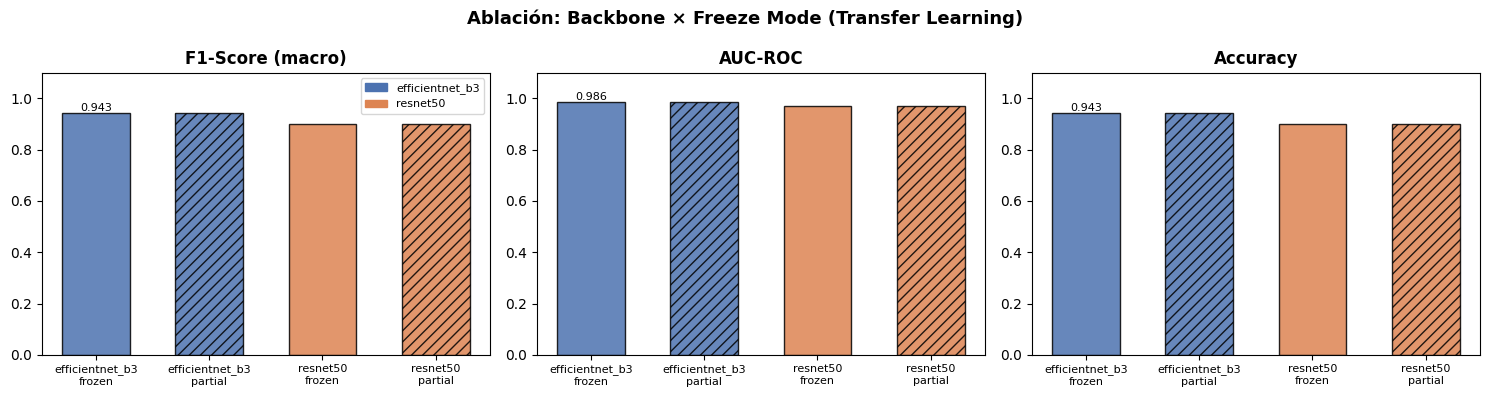

In [11]:
# ── Visualize ablation ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Ablación: Backbone × Freeze Mode (Transfer Learning)', fontsize=13, fontweight='bold')

colors_backbone = {'efficientnet_b3': '#4C72B0', 'resnet50': '#DD8452'}
hatch_freeze    = {'frozen': '', 'partial': '///'}

for ax, (metric, title) in zip(axes, [('val_f1', 'F1-Score (macro)'), ('val_auc', 'AUC-ROC'), ('val_acc', 'Accuracy')]):
    for i, row in df_ablation.iterrows():
        bar = ax.bar(i, row[metric],
                     color=colors_backbone[row['backbone']],
                     hatch=hatch_freeze[row['freeze']],
                     edgecolor='black', alpha=0.85, width=0.6)
    ax.set_xticks(range(len(df_ablation)))
    ax.set_xticklabels([r['config'].replace(' | ', '\n') for _, r in df_ablation.iterrows()], fontsize=8)
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.bar_label(ax.containers[0], fmt='%.3f', fontsize=8)
    if metric == 'val_f1':
        patches = [mpatches.Patch(color=c, label=b) for b, c in colors_backbone.items()]
        ax.legend(handles=patches, fontsize=8)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'ablation_chart.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Sección 4 — Entrenamiento de los Modelos Finales

Se entrena cada backbone en modo **`full` fine-tuning** con **learning rate diferenciado** (backbone recibe LR/10, cabeza recibe LR), que es la estrategia que maximiza la adaptación al dominio sin destruir las representaciones preentrenadas. Se usan las mismas configuraciones de early stopping y scheduling que en el NB1 para comparación justa.

In [12]:
# ── Full training loop for a TL model ────────────────────────────────────────
def train_full(
    backbone_name: str,
    freeze_mode: str = 'full',
    lr: float = 1e-4,
    augmentation: str = 'aggressive',
    label: str = None
) -> tuple:
    """Train a TL model and return (model, history_df, test_metrics, ckpt_path)."""
    label = label or backbone_name
    print(f'\n{"═"*70}')
    print(f'Training: {label} | freeze={freeze_mode} | lr={lr} | aug={augmentation}')
    print('═' * 70)

    set_seed(SEED)
    dl_train, dl_val, dl_test = build_dataloaders(augmentation=augmentation, use_sampler=True)

    model = TireClassifierTL(backbone_name, freeze_mode=freeze_mode).to(DEVICE)
    print(f'  Trainable params: {count_trainable(model):,}')

    # Differential LR for full fine-tuning
    param_groups = model.get_param_groups(lr) if freeze_mode == 'full' else model.parameters()
    optimizer = torch.optim.AdamW(param_groups, lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=3
    )
    scaler = GradScaler()

    ckpt_path = CKPT_DIR / f'best_{label.replace("/","_").replace(" ","_")}.pth'
    best_f1 = 0.0
    patience_ctr = 0
    history = []

    for epoch in range(1, NUM_EPOCHS + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, dl_train, optimizer, CRITERION, scaler, DEVICE)
        val_m = evaluate(model, dl_val, CRITERION, DEVICE)
        scheduler.step(val_m['f1'])
        lr_now = optimizer.param_groups[-1]['lr']  # head LR

        row = {'epoch': epoch, 'lr': lr_now,
               'train_loss': tr_loss, 'train_acc': tr_acc,
               'val_loss': val_m['loss'], 'val_acc': val_m['accuracy'],
               'val_f1': val_m['f1'], 'val_auc': val_m['auc']}
        history.append(row)

        improved = val_m['f1'] > best_f1
        if improved:
            best_f1 = val_m['f1']
            patience_ctr = 0
            torch.save({'epoch': epoch, 'model_state': model.state_dict(),
                        'val_f1': best_f1, 'backbone': backbone_name,
                        'freeze_mode': freeze_mode}, ckpt_path)
        else:
            patience_ctr += 1

        flag = '★' if improved else f'p{patience_ctr}'
        print(f'  Ep {epoch:02d} | tr={tr_loss:.4f}/{tr_acc:.4f} | '
              f'val_f1={val_m["f1"]:.4f} | val_auc={val_m["auc"]:.4f} | '
              f'lr={lr_now:.2e} | {time.time()-t0:.1f}s | {flag}')

        if patience_ctr >= PATIENCE:
            print(f'  Early stopping at epoch {epoch}.')
            break

    # Load best checkpoint and evaluate on test
    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state'])
    test_m = evaluate(model, dl_test, CRITERION, DEVICE)
    print(f'\n  Best val F1={best_f1:.4f} | Test F1={test_m["f1"]:.4f} | Test AUC={test_m["auc"]:.4f}')

    return model, pd.DataFrame(history), test_m, ckpt_path

print('Training function ready.')

Training function ready.


In [13]:
# ── Train EfficientNet-B3 ─────────────────────────────────────────────────────
model_effnet, history_effnet, test_effnet, ckpt_effnet = train_full(
    backbone_name='efficientnet_b3',
    freeze_mode='full',
    lr=1e-4,
    label='efficientnet_b3'
)
history_effnet.to_csv(OUTPUT_DIR / 'training_history_effnet.csv', index=False)


══════════════════════════════════════════════════════════════════════
Training: efficientnet_b3 | freeze=full | lr=0.0001 | aug=aggressive
══════════════════════════════════════════════════════════════════════
  Trainable params: 11,089,961
  Ep 01 | tr=0.0698/0.5391 | val_f1=0.4879 | val_auc=0.9096 | lr=1.00e-04 | 34.2s | ★
  Ep 02 | tr=0.0545/0.6495 | val_f1=0.7590 | val_auc=0.9723 | lr=1.00e-04 | 14.6s | ★
  Ep 03 | tr=0.0454/0.7295 | val_f1=0.9078 | val_auc=0.9783 | lr=1.00e-04 | 15.0s | ★
  Ep 04 | tr=0.0353/0.8452 | val_f1=0.9078 | val_auc=0.9867 | lr=1.00e-04 | 15.0s | p1
  Ep 05 | tr=0.0338/0.8505 | val_f1=0.9149 | val_auc=0.9913 | lr=1.00e-04 | 14.2s | ★
  Ep 06 | tr=0.0309/0.8594 | val_f1=0.9149 | val_auc=0.9877 | lr=1.00e-04 | 13.7s | p1
  Ep 07 | tr=0.0269/0.8772 | val_f1=0.9291 | val_auc=0.9891 | lr=1.00e-04 | 15.1s | ★
  Ep 08 | tr=0.0246/0.9235 | val_f1=0.9290 | val_auc=0.9851 | lr=1.00e-04 | 13.5s | p1
  Ep 09 | tr=0.0264/0.9004 | val_f1=0.9361 | val_auc=0.9904 | lr=1

In [14]:
# ── Train ResNet-50 ───────────────────────────────────────────────────────────
model_resnet, history_resnet, test_resnet, ckpt_resnet = train_full(
    backbone_name='resnet50',
    freeze_mode='full',
    lr=1e-4,
    label='resnet50'
)
history_resnet.to_csv(OUTPUT_DIR / 'training_history_resnet.csv', index=False)


══════════════════════════════════════════════════════════════════════
Training: resnet50 | freeze=full | lr=0.0001 | aug=aggressive
══════════════════════════════════════════════════════════════════════
  Trainable params: 24,032,833
  Ep 01 | tr=0.0752/0.4875 | val_f1=0.3188 | val_auc=0.6613 | lr=1.00e-04 | 15.1s | ★
  Ep 02 | tr=0.0665/0.5142 | val_f1=0.3188 | val_auc=0.8492 | lr=1.00e-04 | 13.8s | p1
  Ep 03 | tr=0.0613/0.5107 | val_f1=0.4764 | val_auc=0.9138 | lr=1.00e-04 | 14.0s | ★
  Ep 04 | tr=0.0568/0.5374 | val_f1=0.7284 | val_auc=0.9492 | lr=1.00e-04 | 14.5s | ★
  Ep 05 | tr=0.0510/0.6637 | val_f1=0.8357 | val_auc=0.9593 | lr=1.00e-04 | 14.3s | ★
  Ep 06 | tr=0.0465/0.7100 | val_f1=0.8135 | val_auc=0.9613 | lr=1.00e-04 | 13.8s | p1
  Ep 07 | tr=0.0463/0.7616 | val_f1=0.8722 | val_auc=0.9667 | lr=1.00e-04 | 15.1s | ★
  Ep 08 | tr=0.0406/0.7758 | val_f1=0.9075 | val_auc=0.9640 | lr=1.00e-04 | 14.7s | ★
  Ep 09 | tr=0.0402/0.8132 | val_f1=0.9078 | val_auc=0.9783 | lr=1.00e-04 

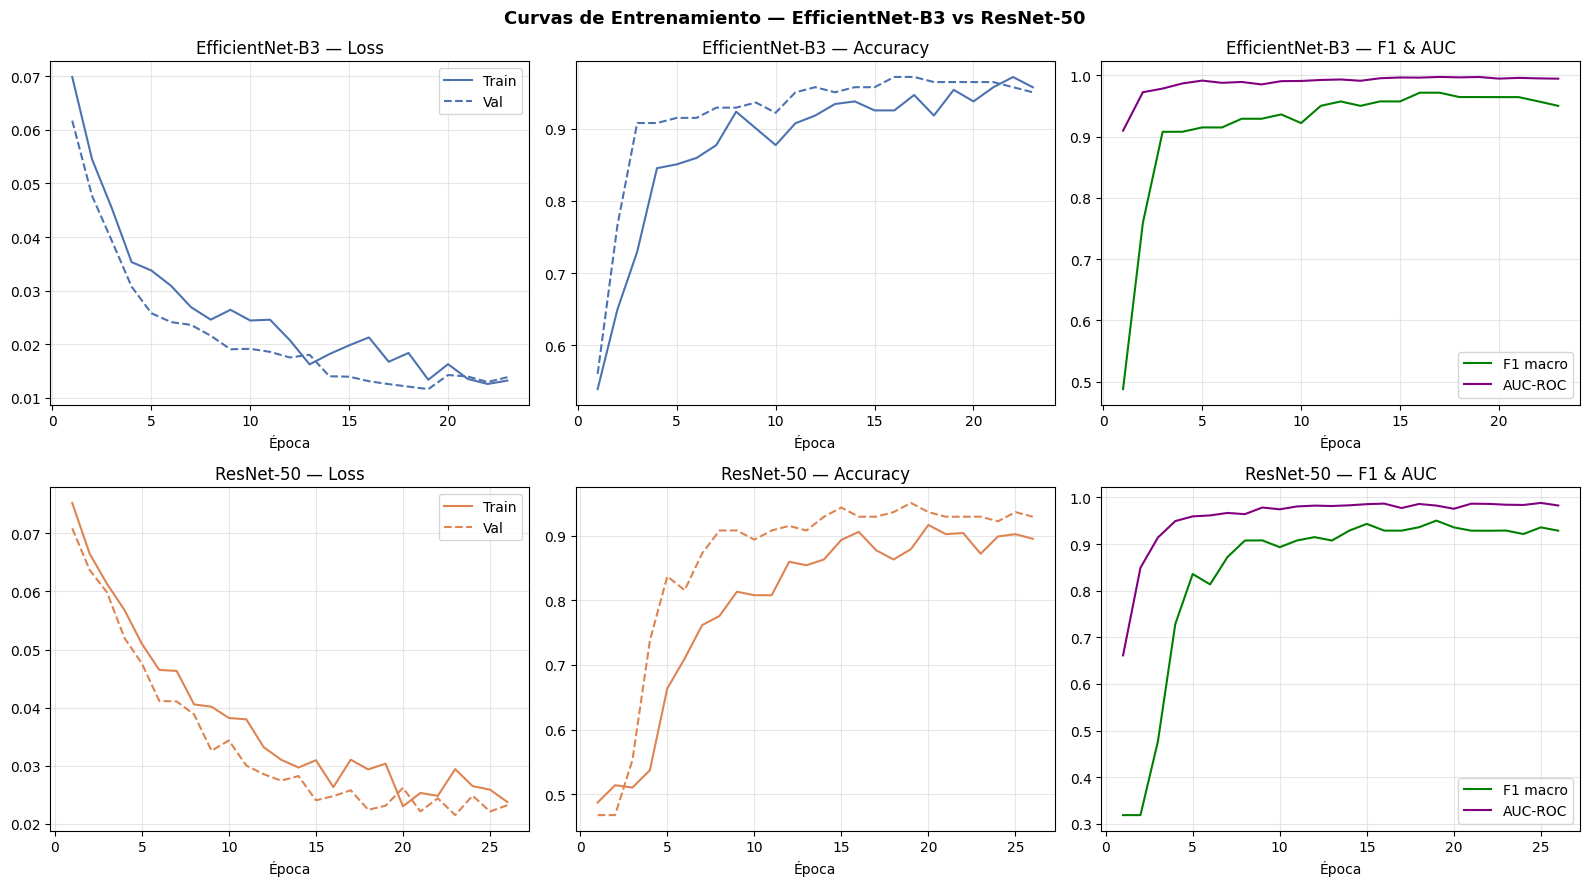

In [15]:
# ── Plot training curves side by side ────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Curvas de Entrenamiento — EfficientNet-B3 vs ResNet-50', fontsize=13, fontweight='bold')

for row_idx, (hist, label, color) in enumerate([
    (history_effnet, 'EfficientNet-B3', '#4C72B0'),
    (history_resnet, 'ResNet-50',       '#DD8452')
]):
    axes[row_idx, 0].plot(hist['epoch'], hist['train_loss'], label='Train', color=color)
    axes[row_idx, 0].plot(hist['epoch'], hist['val_loss'],   label='Val', color=color, linestyle='--')
    axes[row_idx, 0].set_title(f'{label} — Loss'); axes[row_idx, 0].legend()

    axes[row_idx, 1].plot(hist['epoch'], hist['train_acc'], color=color)
    axes[row_idx, 1].plot(hist['epoch'], hist['val_acc'],   color=color, linestyle='--')
    axes[row_idx, 1].set_title(f'{label} — Accuracy')

    axes[row_idx, 2].plot(hist['epoch'], hist['val_f1'],  label='F1 macro', color='green')
    axes[row_idx, 2].plot(hist['epoch'], hist['val_auc'], label='AUC-ROC',  color='purple')
    axes[row_idx, 2].set_title(f'{label} — F1 & AUC'); axes[row_idx, 2].legend()

for ax in axes.flatten():
    ax.grid(alpha=0.3); ax.set_xlabel('Época')

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'training_curves_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Sección 5 — Evaluación Comparativa Completa

Se comparan los tres modelos (TireNet scratch, EfficientNet-B3, ResNet-50) sobre el mismo test set. Para importar métricas del NB1, se carga el CSV exportado previamente desde Drive.

In [16]:
# ── Compute all test metrics per model ───────────────────────────────────────
def full_test_metrics(model_name: str, test_m: dict) -> dict:
    y_true  = test_m['labels']
    y_pred  = test_m['preds']
    y_probs = test_m['probs']
    return {
        'Model':         model_name,
        'Accuracy':      accuracy_score(y_true, y_pred),
        'Precision (M)': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Recall (M)':    recall_score(y_true, y_pred, average='macro', zero_division=0),
        'F1 (macro)':    f1_score(y_true, y_pred, average='macro', zero_division=0),
        'F1 (weighted)': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'AUC-ROC':       roc_auc_score(y_true, y_probs),
    }

# Build comparison table
results_rows = [
    full_test_metrics('EfficientNet-B3 (TL)', test_effnet),
    full_test_metrics('ResNet-50 (TL)',        test_resnet),
]

# Try to load NB1 results from Drive for 3-way comparison
nb1_metrics_path = Path('/content/drive/MyDrive/tire_classification/nb1_cnn_scratch/metrics_summary.csv')
if nb1_metrics_path.exists():
    df_nb1 = pd.read_csv(nb1_metrics_path)
    nb1_row = df_nb1.iloc[0]
    results_rows.insert(0, {
        'Model': 'TireNet (CNN Scratch)',
        'Accuracy':      nb1_row.get('accuracy', float('nan')),
        'Precision (M)': nb1_row.get('precision_macro', float('nan')),
        'Recall (M)':    nb1_row.get('recall_macro', float('nan')),
        'F1 (macro)':    nb1_row.get('f1_macro', float('nan')),
        'F1 (weighted)': nb1_row.get('f1_weighted', float('nan')),
        'AUC-ROC':       nb1_row.get('auc_roc', float('nan')),
    })
    print('NB1 metrics loaded from Drive.')
else:
    print('NB1 metrics not found in Drive — run NB1 first and mount Drive.')

df_comparison = pd.DataFrame(results_rows)
df_comparison = df_comparison.set_index('Model')
print('\n=== Comparación Final de Modelos (Test Set) ===')
print(df_comparison.round(4).to_string())
df_comparison.to_csv(OUTPUT_DIR / 'final_comparison.csv')

NB1 metrics not found in Drive — run NB1 first and mount Drive.

=== Comparación Final de Modelos (Test Set) ===
                      Accuracy  Precision (M)  Recall (M)  F1 (macro)  F1 (weighted)  AUC-ROC
Model                                                                                        
EfficientNet-B3 (TL)    0.7108         0.7439      0.7585      0.7098         0.7147   0.8906
ResNet-50 (TL)          0.6708         0.7261      0.7295      0.6707         0.6719   0.8096


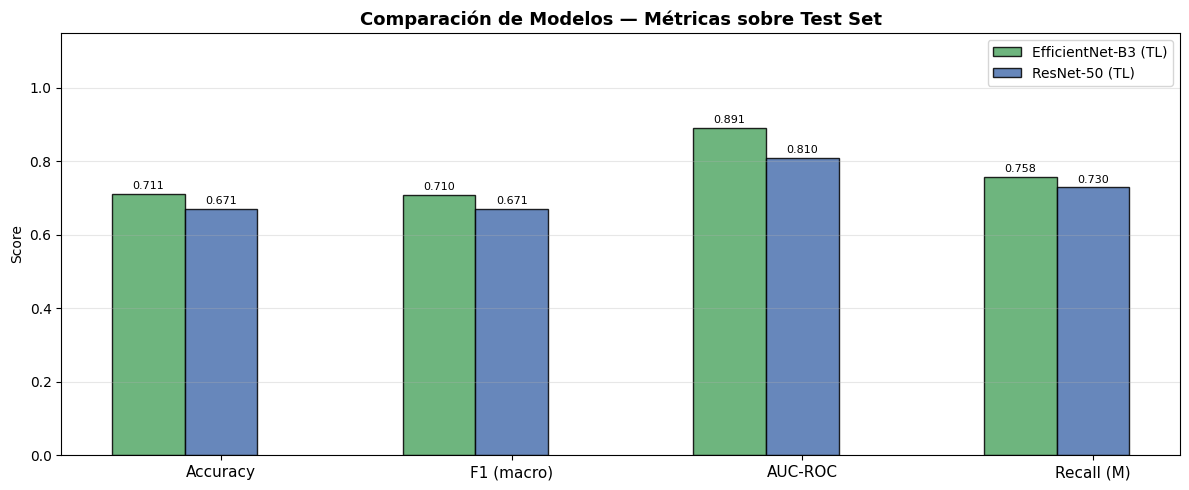

In [17]:
# ── Comparison bar chart ───────────────────────────────────────────────────────
metrics_to_show = ['Accuracy', 'F1 (macro)', 'AUC-ROC', 'Recall (M)']
x = np.arange(len(metrics_to_show))
width = 0.25
colors_models = ['#55A868', '#4C72B0', '#DD8452']

fig, ax = plt.subplots(figsize=(12, 5))
for i, (model_name, row) in enumerate(df_comparison.iterrows()):
    vals = [row.get(m, 0) for m in metrics_to_show]
    bars = ax.bar(x + i * width, vals, width, label=model_name,
                  color=colors_models[i % len(colors_models)], edgecolor='black', alpha=0.85)
    ax.bar_label(bars, fmt='%.3f', fontsize=8, padding=2)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_to_show, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Comparación de Modelos — Métricas sobre Test Set', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'model_comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()

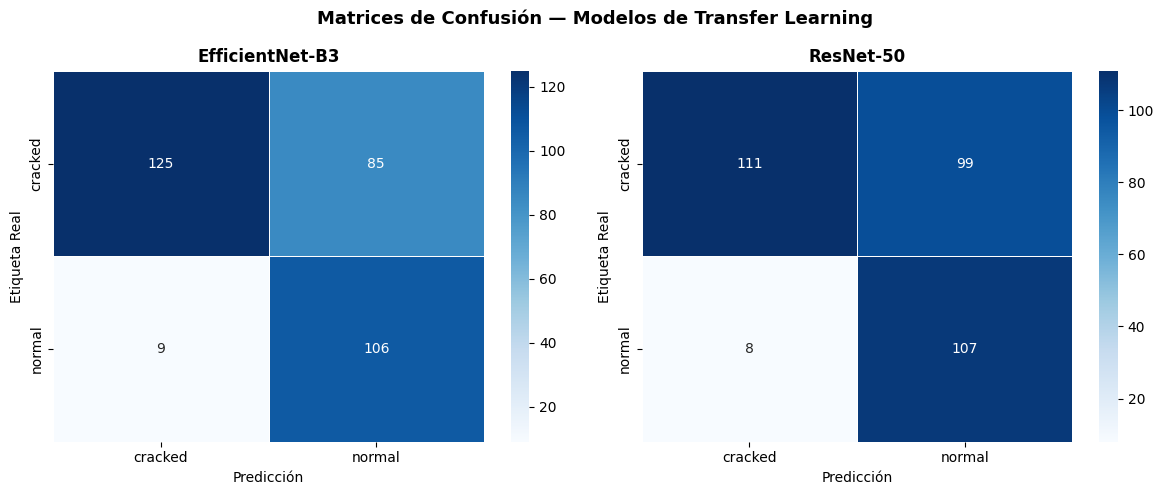

In [18]:
# ── Confusion matrices for both TL models ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Matrices de Confusión — Modelos de Transfer Learning', fontsize=13, fontweight='bold')

for ax, (name, tm) in zip(axes, [
    ('EfficientNet-B3', test_effnet),
    ('ResNet-50',       test_resnet)
]):
    cm = confusion_matrix(tm['labels'], tm['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=CLASSES, yticklabels=CLASSES, linewidths=0.5)
    ax.set_title(f'{name}', fontweight='bold')
    ax.set_xlabel('Predicción'); ax.set_ylabel('Etiqueta Real')

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'confusion_matrices_tl.png', dpi=150, bbox_inches='tight')
plt.show()

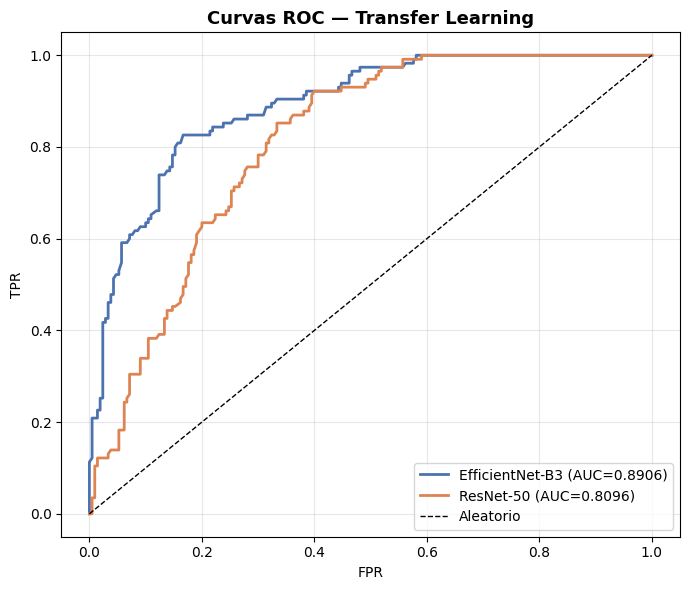

In [19]:
# ── Combined ROC curves ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
plot_configs = [
    ('EfficientNet-B3', test_effnet, '#4C72B0'),
    ('ResNet-50',       test_resnet, '#DD8452'),
]

for name, tm, color in plot_configs:
    fpr, tpr, _ = roc_curve(tm['labels'], tm['probs'])
    auc_score = roc_auc_score(tm['labels'], tm['probs'])
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc_score:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Aleatorio')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('Curvas ROC — Transfer Learning', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'roc_curves_tl.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# ── Save test predictions for both models ────────────────────────────────────
for model_tag, tm in [('effnet', test_effnet), ('resnet', test_resnet)]:
    # Collect paths
    dl_test_tmp = build_dataloaders(augmentation='aggressive', use_sampler=True)[2]
    paths = []
    for _, _, p in dl_test_tmp:
        paths.extend(p)

    pd.DataFrame({
        'image_path':  paths[:len(tm['labels'])],
        'true_label':  [CLASSES[l] for l in tm['labels']],
        'pred_label':  [CLASSES[p] for p in tm['preds']],
        'prob_cracked': tm['probs'],
        'correct':     [t == p for t, p in zip(tm['labels'], tm['preds'])],
    }).to_csv(OUTPUT_DIR / f'test_predictions_{model_tag}.csv', index=False)
    print(f'Predictions saved: test_predictions_{model_tag}.csv')

Predictions saved: test_predictions_effnet.csv
Predictions saved: test_predictions_resnet.csv


In [21]:
# ── Save metrics summary ──────────────────────────────────────────────────────
df_comparison.reset_index().to_csv(OUTPUT_DIR / 'metrics_summary.csv', index=False)
print('metrics_summary.csv guardado.')

metrics_summary.csv guardado.


---
## Sección 6 — Interpretabilidad con Grad-CAM

Para **EfficientNet-B3**, el target layer es el último bloque convolucional del backbone (`conv_head` o el último bloque `blocks`). Para **ResNet-50**, es la última capa del bloque `layer4`. Ambos producen mapas de activación de 7×7 que se interpolan bilinealmente a la resolución de entrada.

In [22]:
# ── Define target layers for Grad-CAM ─────────────────────────────────────────
def get_target_layer(model: TireClassifierTL) -> list:
    """Return the last convolutional layer appropriate for Grad-CAM."""
    backbone = model.backbone
    name = model.backbone_name

    if 'efficientnet' in name:
        # Last conv layer before global pooling in EfficientNet
        return [backbone.conv_head]
    elif 'resnet' in name:
        # Last block of layer4 in ResNet
        return [backbone.layer4[-1].conv3]
    else:
        # Fallback: try to find last Conv2d
        last_conv = None
        for m in backbone.modules():
            if isinstance(m, nn.Conv2d):
                last_conv = m
        return [last_conv]


def generate_gradcam_grid(model, model_name: str, df_preds: pd.DataFrame,
                           save_dir: Path, n_per_case: int = 2):
    """Generate Grad-CAM visualizations: n correct + n wrong per class."""
    target_layers = get_target_layer(model)
    cam_obj = GradCAM(model=model, target_layers=target_layers)

    # Build sample list defensively
    cam_samples = []
    for true_cls in CLASSES:
        for correct in [True, False]:
            sub = df_preds[
                (df_preds['true_label'] == true_cls) &
                (df_preds['correct'] == correct)
            ]
            if sub.empty:
                print(f'  [SKIP] {model_name}: class={true_cls}, correct={correct}')
                continue
            sampled = sub.sample(min(n_per_case, len(sub)), random_state=SEED)
            cam_samples.extend(sampled.to_dict('records'))

    saved = []
    for i, row in enumerate(cam_samples):
        img_pil = Image.open(row['image_path']).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
        img_np  = np.array(img_pil, dtype=np.float32) / 255.0
        tensor  = transform_eval(img_pil).unsqueeze(0).to(DEVICE)

        # Binary model has a single output neuron → target index always 0
        targets = [ClassifierOutputTarget(0)]
        gcam    = cam_obj(input_tensor=tensor, targets=targets)[0]
        cam_img = show_cam_on_image(img_np, gcam, use_rgb=True)

        true_idx = int(row['true_idx'])
        pred_idx = int(row['pred_idx'])

        fig, axes = plt.subplots(1, 2, figsize=(8, 4))
        axes[0].imshow(img_np); axes[0].axis('off')
        axes[0].set_title('Original', fontweight='bold')

        status = '✓' if row['correct'] else '✗'
        color  = 'green' if row['correct'] else 'red'
        axes[1].imshow(cam_img); axes[1].axis('off')
        axes[1].set_title(
            f'{status} Real: {CLASSES[true_idx]} | '
            f'Pred: {CLASSES[pred_idx]}\n'
            f'p={row["prob_cracked"]:.2f}',
            color=color, fontweight='bold', fontsize=9
        )

        fname = save_dir / (
            f'{model_name}_gcam_{i+1:02d}_'
            f'{row["true_label"]}_{"ok" if row["correct"] else "err"}.png'
        )
        plt.tight_layout()
        fig.savefig(fname, dpi=120, bbox_inches='tight')
        plt.close(fig)
        saved.append(fname)

    print(f'Saved {len(saved)} Grad-CAM images for {model_name}')
    return saved


print('Grad-CAM utilities ready.')

Grad-CAM utilities ready.


In [23]:
# ── Load predictions DataFrames ────────────────────────────────────────────────
df_effnet_preds = pd.read_csv(OUTPUT_DIR / 'test_predictions_effnet.csv')
df_resnet_preds = pd.read_csv(OUTPUT_DIR / 'test_predictions_resnet.csv')

# Rebuild idx columns safely
for df in [df_effnet_preds, df_resnet_preds]:
    df['true_idx'] = df['true_label'].map(CLASS2IDX).astype(int)
    df['pred_idx'] = df['pred_label'].map(CLASS2IDX).astype(int)

print(f'EfficientNet-B3 predictions: {len(df_effnet_preds)} | '
      f'errors: {(~df_effnet_preds["correct"]).sum()}')
print(f'ResNet-50 predictions:       {len(df_resnet_preds)} | '
      f'errors: {(~df_resnet_preds["correct"]).sum()}')

# ── Generate Grad-CAM for EfficientNet-B3 ────────────────────────────────────
effnet_gcam_files = generate_gradcam_grid(
    model_effnet, 'effnet', df_effnet_preds, GRADCAM_DIR
)

# ── Generate Grad-CAM for ResNet-50 ──────────────────────────────────────────
resnet_gcam_files = generate_gradcam_grid(
    model_resnet, 'resnet', df_resnet_preds, GRADCAM_DIR
)

EfficientNet-B3 predictions: 325 | errors: 94
ResNet-50 predictions:       325 | errors: 107
Saved 8 Grad-CAM images for effnet
Saved 8 Grad-CAM images for resnet


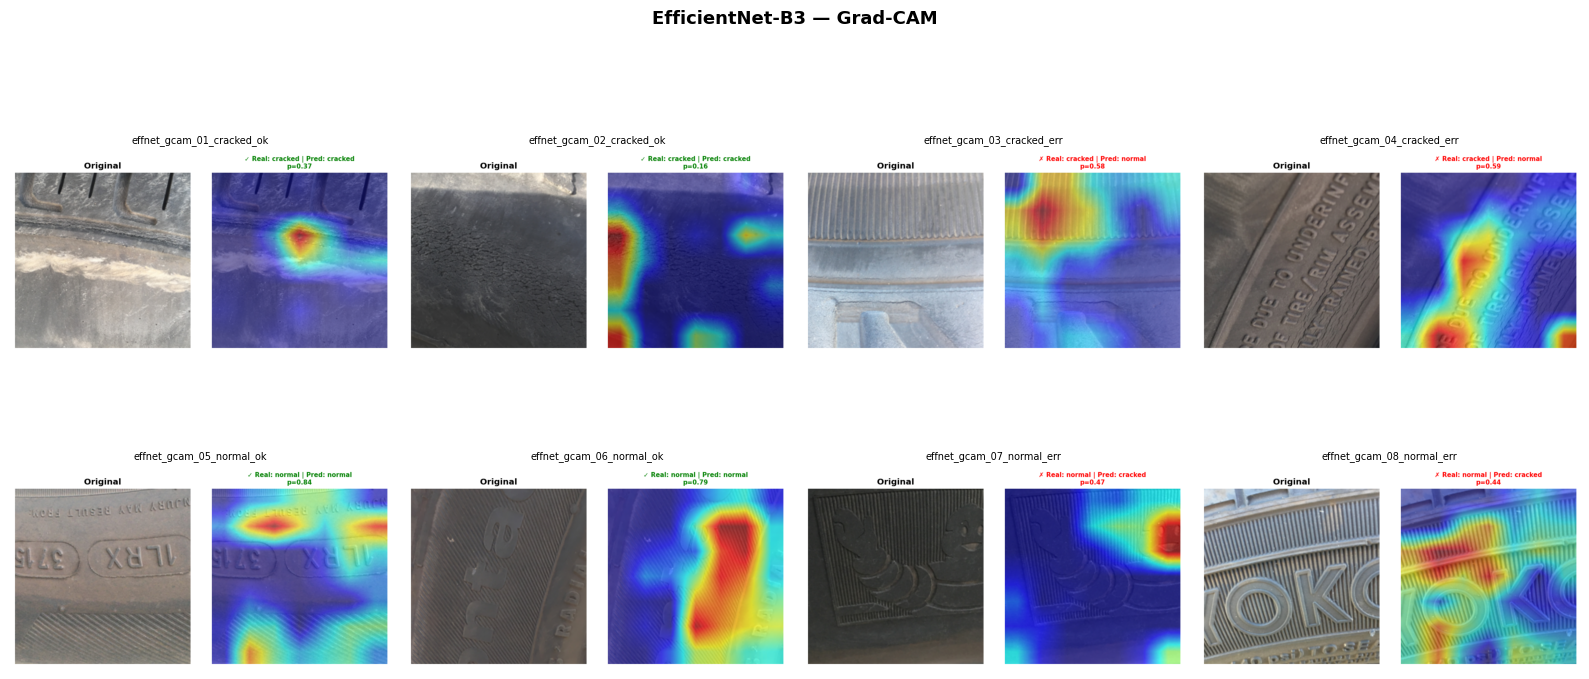

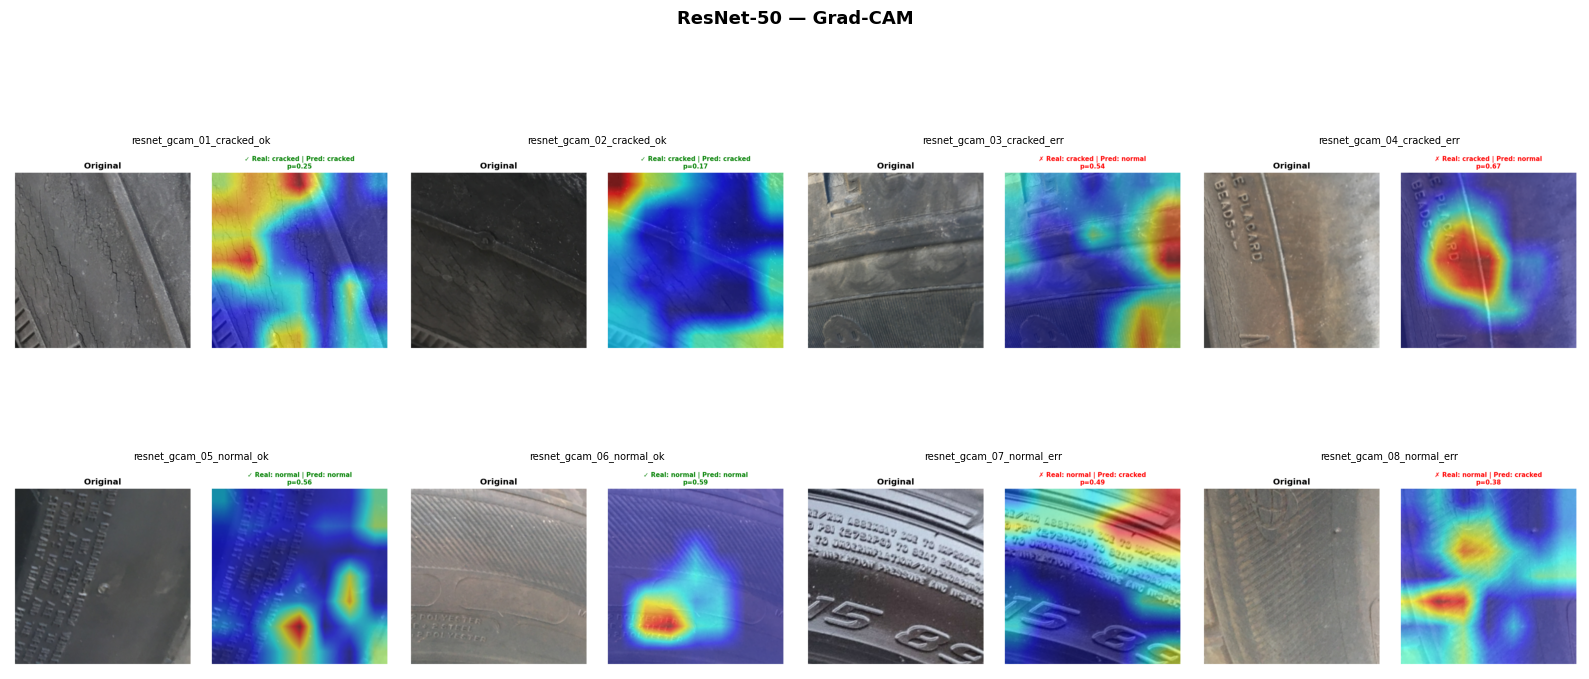

In [24]:
# ── Display Grad-CAM grids ────────────────────────────────────────────────────
for files_list, title in [
    (effnet_gcam_files, 'EfficientNet-B3 — Grad-CAM'),
    (resnet_gcam_files, 'ResNet-50 — Grad-CAM')
]:
    n = len(files_list)
    cols = 4
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    for ax, fpath in zip(axes.flatten(), files_list):
        ax.imshow(Image.open(fpath))
        ax.axis('off')
        ax.set_title(fpath.stem[-30:], fontsize=7)
    for ax in axes.flatten()[n:]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

---
## Sección 7 — Análisis Cualitativo de Fallos

In [25]:
# ── Extract and analyze failures for both models ──────────────────────────────
def analyze_failures(df_preds: pd.DataFrame, model: nn.Module,
                      model_name: str, save_dir: Path, n_top: int = 8):
    df_err = df_preds[~df_preds['correct']].copy()
    df_err['confidence_wrong'] = df_err.apply(
        lambda r: r['prob_cracked'] if r['pred_label'] == 'cracked'
                  else 1 - r['prob_cracked'],
        axis=1
    )
    df_err = df_err.sort_values('confidence_wrong', ascending=False)
    top_n  = df_err.head(n_top).reset_index(drop=True)

    print(f'\n{model_name} — Total errores: {len(df_err)} / {len(df_preds)}')
    print(f'  Error rate: {len(df_err)/len(df_preds)*100:.1f}%')
    print(top_n[['true_label','pred_label','prob_cracked','confidence_wrong']].to_string())

    target_layers = get_target_layer(model)
    cam_obj = GradCAM(model=model, target_layers=target_layers)

    cols = 4
    rows = (len(top_n) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4.5))
    fig.suptitle(f'Fallos Más Confiados — {model_name}',
                 fontsize=13, fontweight='bold', color='red')

    for i, (_, row) in enumerate(top_n.iterrows()):
        ax = axes.flatten()[i]
        img_pil = Image.open(row['image_path']).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
        img_np  = np.array(img_pil, dtype=np.float32) / 255.0
        tensor  = transform_eval(img_pil).unsqueeze(0).to(DEVICE)

        # Binary scalar output → target index always 0
        targets = [ClassifierOutputTarget(0)]
        gcam    = cam_obj(input_tensor=tensor, targets=targets)[0]
        cam_img = show_cam_on_image(img_np, gcam, use_rgb=True)

        ax.imshow(cam_img)
        error_type = 'FP' if row['pred_label'] == 'cracked' else 'FN'
        ax.set_title(f'#{i+1} {error_type} | conf={row["confidence_wrong"]:.2f}',
                     fontsize=9, color='red', fontweight='bold')
        ax.axis('off')

    for ax in axes.flatten()[len(top_n):]:
        ax.axis('off')

    plt.tight_layout()
    grid_path = save_dir / f'failure_grid_{model_name}.png'
    fig.savefig(grid_path, dpi=120, bbox_inches='tight')
    plt.show()

    top_n['error_type'] = top_n.apply(
        lambda r: 'FP' if r['pred_label'] == 'cracked' else 'FN', axis=1
    )
    top_n['hypothesis'] = ''
    csv_path = save_dir / f'failure_analysis_{model_name}.csv'
    top_n[['image_path','true_label','pred_label','prob_cracked',
            'confidence_wrong','error_type','hypothesis']].to_csv(csv_path, index=False)
    print(f'  Saved: {csv_path.name}')
    return top_n


fails_effnet = analyze_failures(df_effnet_preds, model_effnet, 'EfficientNet-B3', FAILURE_DIR)
fails_resnet = analyze_failures(df_resnet_preds, model_resnet, 'ResNet-50',       FAILURE_DIR)

Output hidden; open in https://colab.research.google.com to view.

---
## Sección 8 — Exportación de Artefactos

In [27]:
import shutil
from google.colab import files

shutil.make_archive("/content/nb2_transfer_learning", "zip", "/content/outputs/nb2_transfer_learning")
files.download("/content/nb2_transfer_learning.zip")

shutil.make_archive("/content/sample_data", "zip", "/content/sample_data")
files.download("/content/sample_data.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Resumen de Resultados — Notebook 2

> **Completa esta tabla después de ejecutar el notebook con los valores reales.**

### Comparación Final de los Tres Modelos

| Modelo | Accuracy | F1 (macro) | AUC-ROC | Params (M) |
|---|---|---|---|---|
| TireNet (CNN Scratch) | `rellenar` | `rellenar` | `rellenar` | `rellenar` |
| EfficientNet-B3 (TL) | `rellenar` | `rellenar` | `rellenar` | `rellenar` |
| ResNet-50 (TL) | `rellenar` | `rellenar` | `rellenar` | `rellenar` |

### Conclusiones del Estudio de Ablación (NB2)
> Comparar `frozen` vs `partial` para cada backbone. ¿Cuánto mejora el unfreezing parcial? ¿Es significativa la diferencia?

### Análisis Comparativo Grad-CAM
> ¿Difieren las regiones de activación entre EfficientNet y ResNet para la misma imagen? ¿Cuál focaliza más en grietas específicas?

### Hipótesis sobre Fallos
| # | Modelo | Tipo | Hipótesis |
|---|---|---|---|
| 1 | EfficientNet-B3 | FP/FN | `rellenar` |
| 2 | EfficientNet-B3 | FP/FN | `rellenar` |
| 3 | ResNet-50 | FP/FN | `rellenar` |
| 4 | ResNet-50 | FP/FN | `rellenar` |
| 5 | Ambos | FP/FN | `rellenar` |